In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv
/kaggle/input/datasets/lava18/google-play-store-apps/license.txt
/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv
/kaggle/input/datasets/shivkumarganesh/tinder-google-play-store-review/tinder_google_play_reviews.csv
/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv
/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv
/kaggle/input/datasets/shivkumarganesh/tinder-google-play-store-review/tinder_google_play_reviews.csv


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
apps_path = "/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv"
reviews_path = "/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv"

# Load datasets
apps = pd.read_csv(apps_path)
reviews = pd.read_csv(reviews_path)

print("Apps dataset loaded successfully!")
print("Reviews dataset loaded successfully!")

print("\nApps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

print("\nFirst 5 rows of Apps dataset:")
display(apps.head())

print("\nFirst 5 rows of Reviews dataset:")
display(reviews.head())

Apps dataset loaded successfully!
Reviews dataset loaded successfully!

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)

First 5 rows of Apps dataset:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



First 5 rows of Reviews dataset:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [52]:
print("Apps Dataset Columns:")
print(apps.columns.tolist())

print("\nApps Dataset Data Types:")
print(apps.dtypes)

print("\nApps Dataset Missing Values:")
print(apps.isnull().sum())

print("\nApps Dataset Duplicate Rows:")
print(apps.duplicated().sum())

Apps Dataset Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Apps Dataset Data Types:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Apps Dataset Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Apps Dataset Duplicate Rows:
483


In [53]:
print("Reviews Dataset Columns:")
print(reviews.columns.tolist())

print("\nReviews Dataset Data Types:")
print(reviews.dtypes)

print("\nReviews Dataset Missing Values:")
print(reviews.isnull().sum())

print("\nReviews Dataset Duplicate Rows:")
print(reviews.duplicated().sum())

Reviews Dataset Columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Reviews Dataset Data Types:
App                        object
Translated_Review          object
Sentiment                  object
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object

Reviews Dataset Missing Values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Reviews Dataset Duplicate Rows:
33616


## 1. Data Loading and Initial Inspection

Two datasets were used for the analysis:

1. Google Play Store Apps dataset
2. Google Play Store User Reviews dataset

The initial inspection examines the dataset dimensions, column names, data types, missing values, and duplicate records.

This step helps identify data-quality issues that need to be addressed before performing exploratory and sentiment analysis.

## 2. Data Cleaning

The Google Play Store dataset contains duplicate records, missing values, and several numerical columns stored as text.

The following cleaning steps are performed:

- Remove duplicate app records
- Handle missing ratings
- Fill missing categorical values
- Convert Reviews, Size, Installs, and Price into numerical formats
- Prepare the dataset for exploratory analysis

In [54]:
# Check duplicates before cleaning
print("Duplicates before cleaning:", apps.duplicated().sum())

# Remove duplicate rows
apps = apps.drop_duplicates()

print("Duplicates after cleaning:", apps.duplicated().sum())
print("Dataset shape after removing duplicates:", apps.shape)

Duplicates before cleaning: 483
Duplicates after cleaning: 0
Dataset shape after removing duplicates: (10358, 13)


In [55]:
# Fill missing Rating values with the median
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

# Fill missing categorical values with the mode
apps["Type"] = apps["Type"].fillna(apps["Type"].mode()[0])
apps["Content Rating"] = apps["Content Rating"].fillna(
    apps["Content Rating"].mode()[0]
)
apps["Current Ver"] = apps["Current Ver"].fillna(
    apps["Current Ver"].mode()[0]
)
apps["Android Ver"] = apps["Android Ver"].fillna(
    apps["Android Ver"].mode()[0]
)

print("Missing values after cleaning:")
print(apps.isnull().sum())

Missing values after cleaning:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


In [56]:
apps["Reviews"] = pd.to_numeric(
    apps["Reviews"],
    errors="coerce"
)

print("Reviews data type:", apps["Reviews"].dtype)

Reviews data type: float64


In [57]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps["Installs"] = pd.to_numeric(
    apps["Installs"],
    errors="coerce"
)

print("Installs data type:", apps["Installs"].dtype)

Installs data type: float64


In [58]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(
    apps["Price"],
    errors="coerce"
)

print("Price data type:", apps["Price"].dtype)

Price data type: float64


In [59]:
print("Final Dataset Shape:", apps.shape)

print("\nRemaining Missing Values:")
print(apps.isnull().sum())

print("\nFinal Data Types:")
print(apps.dtypes)

Final Dataset Shape: (10358, 13)

Remaining Missing Values:
App               0
Category          0
Rating            0
Reviews           1
Size              0
Installs          1
Type              0
Price             1
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Final Data Types:
App                object
Category           object
Rating            float64
Reviews           float64
Size               object
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


In [60]:
# Fill remaining numerical missing values with the median
apps["Reviews"] = apps["Reviews"].fillna(apps["Reviews"].median())
apps["Installs"] = apps["Installs"].fillna(apps["Installs"].median())
apps["Price"] = apps["Price"].fillna(apps["Price"].median())

print("Remaining missing values:")
print(apps.isnull().sum().sum())

Remaining missing values:
0


In [61]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size)
    
    if size == "Varies with device":
        return np.nan
    
    if size.endswith("M"):
        return float(size[:-1])
    
    if size.endswith("k"):
        return float(size[:-1]) / 1024
    
    return np.nan


apps["Size_MB"] = apps["Size"].apply(convert_size)

print("Size conversion completed.")
display(apps[["Size", "Size_MB"]].head(10))

Size conversion completed.


,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


In [62]:
print("Final shape:", apps.shape)

print("\nMissing values:")
print(apps.isnull().sum())

print("\nNumerical summary:")
display(apps.describe())

Final shape: (10358, 14)

Missing values:
App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
Size_MB           1527
dtype: int64

Numerical summary:


,Rating,Reviews,Installs,Price,Size_MB
count,10358.000000,1.035800e+04,1.035800e+04,10358.000000,8831.000000
mean,4.205165,4.058656e+05,1.415640e+07,1.030701,21.287413
std,0.506868,2.696651e+06,8.023580e+07,16.277843,22.540591
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.008301
25%,4.100000,3.200000e+01,1.000000e+03,0.000000,4.700000
50%,4.300000,1.680000e+03,1.000000e+05,0.000000,13.000000
75%,4.500000,4.640425e+04,1.000000e+06,0.000000,29.000000
max,19.000000,7.815831e+07,1.000000e+09,400.000000,100.000000


## 3. App Category Analysis

The Google Play Store contains apps across many different categories.

This analysis identifies the most common app categories and examines the distribution of apps across categories. Understanding category distribution helps identify which areas have the greatest number of applications.

In [63]:
# Count apps in each category
category_counts = apps["Category"].value_counts()

print("Number of apps by category:")
display(category_counts)

Number of apps by category:


Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

In [64]:
# Count apps in each category
category_counts = apps["Category"].value_counts()

print("Number of apps by category:")
display(category_counts)

Number of apps by category:


Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

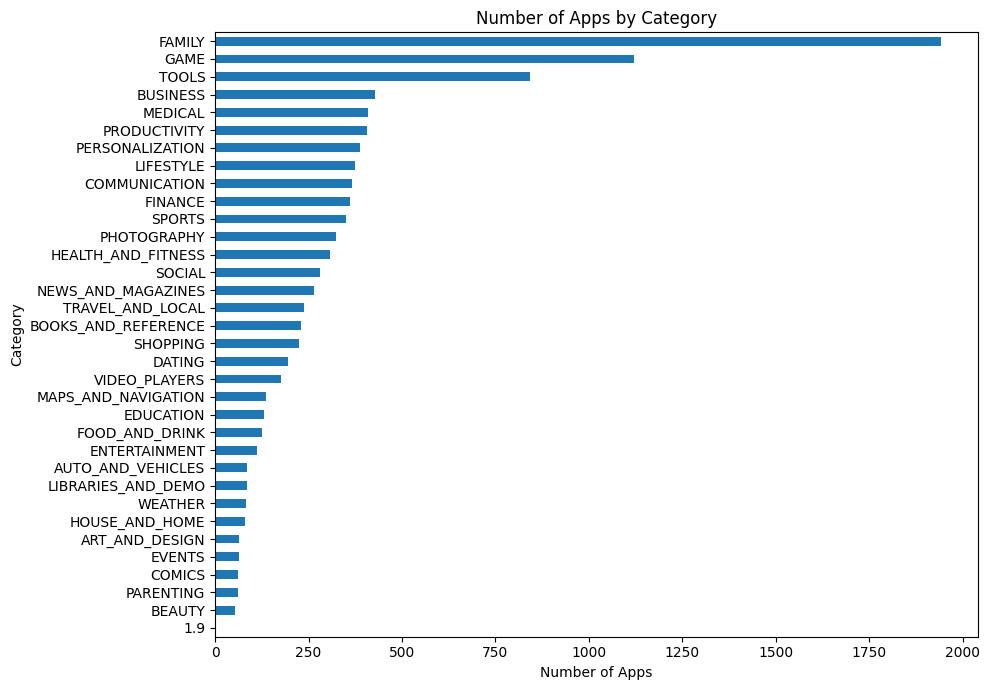

In [65]:
plt.figure(figsize=(10, 7))

category_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Top 10 App Categories

The top 10 categories are identified based on the number of applications available in the dataset.

In [66]:
top_10_categories = apps["Category"].value_counts().head(10)

print("Top 10 App Categories:")
display(top_10_categories)

Top 10 App Categories:


Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

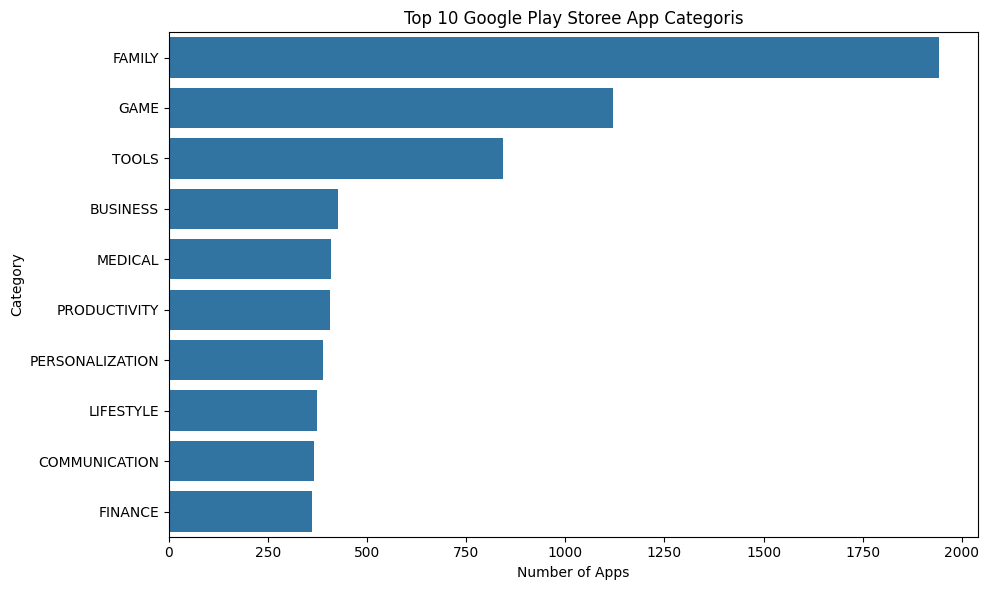

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_categories.values,
    y=top_10_categories.index
)

plt.title("Top 10 Google Play Storee App Categoris")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [68]:
category_ratings = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Category:")
display(category_ratings)

Average Rating by Category:


Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
PERSONALIZATION         4.327062
PARENTING               4.300000
BEAUTY                  4.283019
GAME                    4.282070
HEALTH_AND_FITNESS      4.266993
SOCIAL                  4.260714
SHOPPING                4.256250
WEATHER                 4.248780
SPORTS                  4.239031
PRODUCTIVITY            4.219410
MEDICAL                 4.212990
LIBRARIES_AND_DEMO      4.207059
AUTO_AND_VEHICLES       4.205882
FAMILY                  4.203757
PHOTOGRAPHY             4.189441
HOUSE_AND_HOME          4.185000
FOOD_AND_DRINK          4.183871
COMMUNICATION           4.175410
BUSINESS                4.175176
NEWS_AND_MAGAZINES      4.160985
COMICS                  4.160000
FINANCE                 4.148056
ENTERTAINMENT           4.136036
LIFESTYLE               4.133244
TRAVEL_AND_LOCAL        4.121941
V

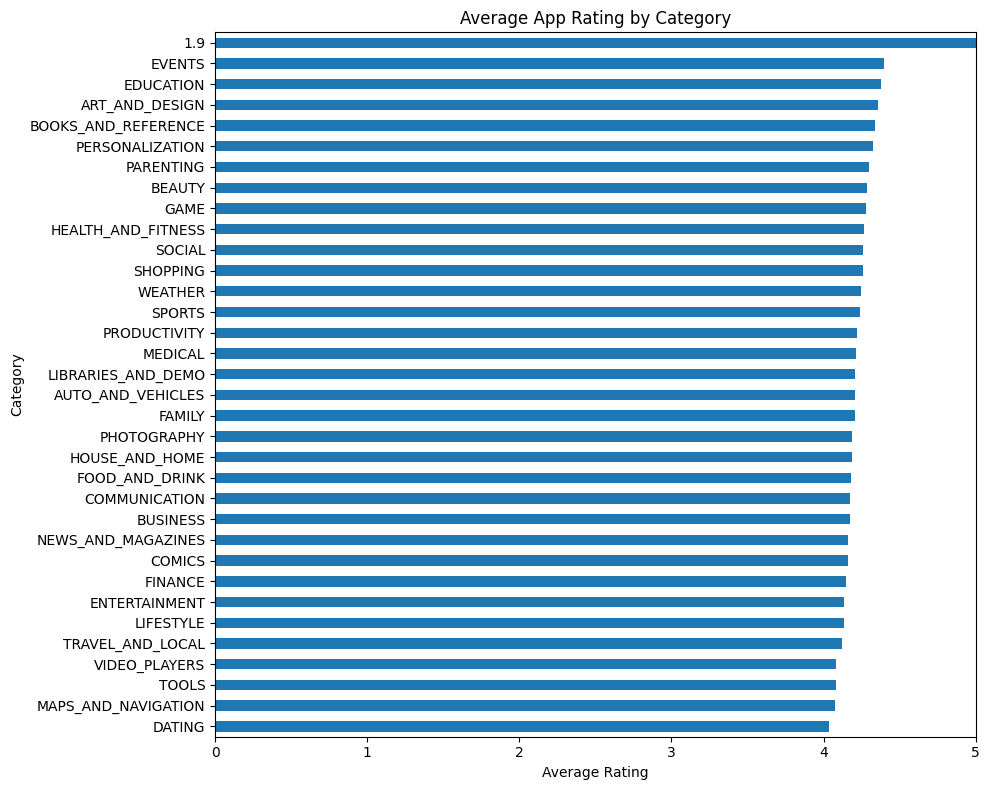

In [69]:
plt.figure(figsize=(10, 8))

category_ratings.sort_values().plot(
    kind="barh"
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.xlim(0, 5)
plt.tight_layout()
plt.show()

## 4. Rating Analysis

App ratings provide an indication of user satisfaction.

The distribution of ratings is analyzed to understand the overall quality of apps and identify the most common rating ranges.

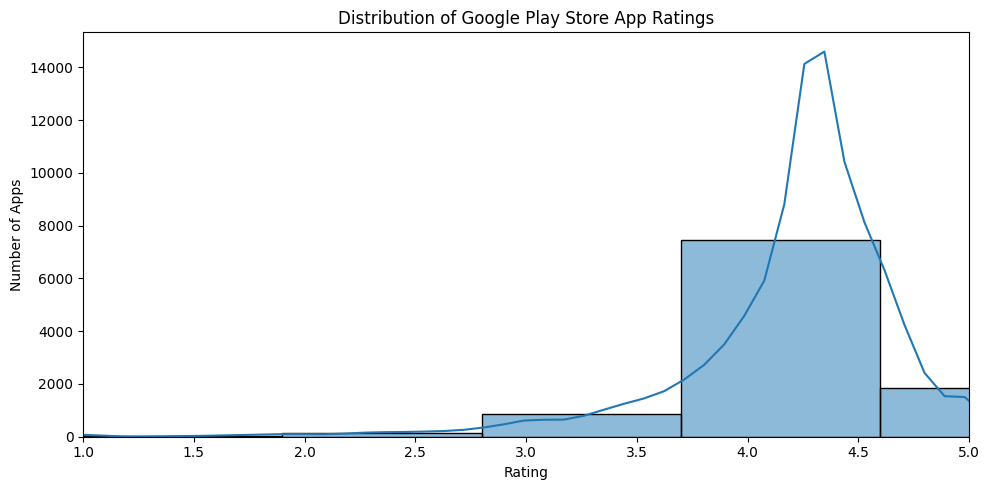

In [70]:
plt.figure(figsize=(10, 5))

sns.histplot(
    apps["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of Google Play Store App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.xlim(1, 5)
plt.tight_layout()
plt.show()

In [71]:
def rating_category(rating):
    if rating < 3:
        return "Low"
    elif rating < 4:
        return "Medium"
    else:
        return "High"

apps["Rating_Category"] = apps["Rating"].apply(rating_category)

print("Rating Category Distribution:")
display(apps["Rating_Category"].value_counts())

Rating Category Distribution:


Rating_Category
High      8413
Medium    1665
Low        280
Name: count, dtype: int64

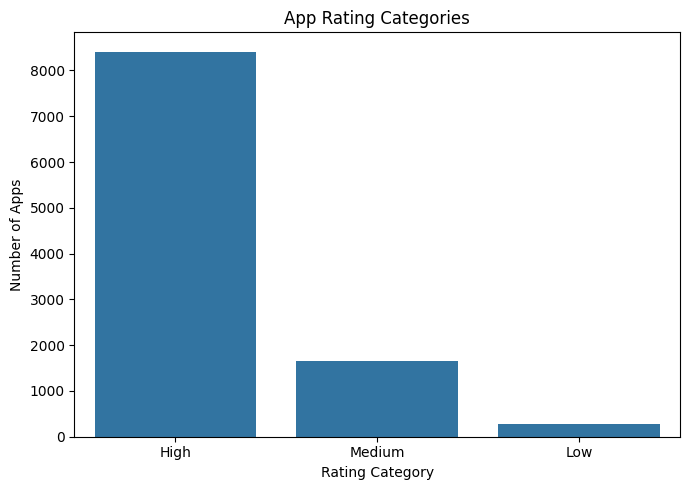

In [72]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=apps,
    x="Rating_Category"
)

plt.title("App Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

### Reviews vs App Ratings

The relationship between the number of user reviews and app ratings is examined to determine whether user engagement is associated with app ratings.

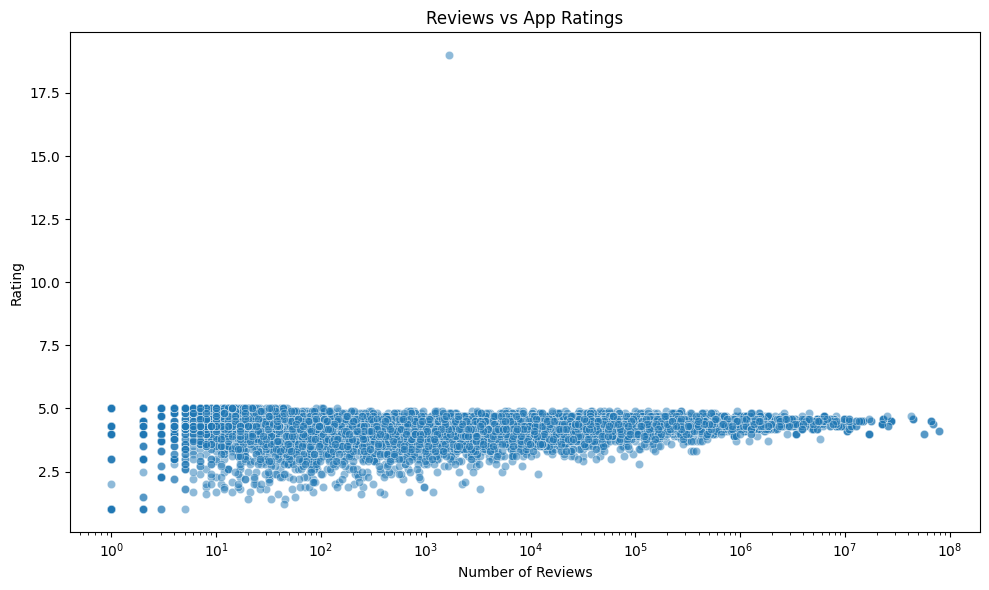

In [73]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=apps,
    x="Reviews",
    y="Rating",
    alpha=0.5
)

plt.title("Reviews vs App Ratings")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.xscale("log")
plt.tight_layout()
plt.show()

In [74]:
print("App Type Distribution:")
display(apps["Type"].value_counts())

App Type Distribution:


Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64

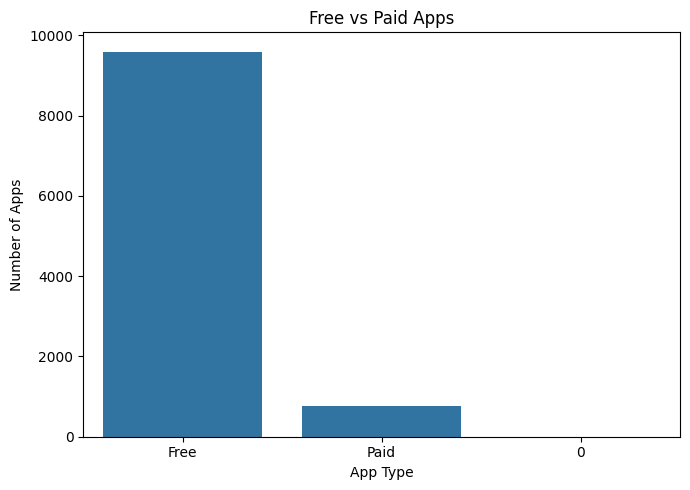

In [75]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=apps,
    x="Type"
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

## 5. App Size and Install Analysis

App size can influence whether users choose to download an application, particularly when storage space or internet bandwidth is limited.

The relationship between application size and the number of installs is analyzed to identify whether app size appears to influence popularity.

In [76]:
# Remove rows where Size_MB is unavailable
size_analysis = apps.dropna(subset=["Size_MB", "Installs"]).copy()

print("Records available for size analysis:", len(size_analysis))

Records available for size analysis: 8831


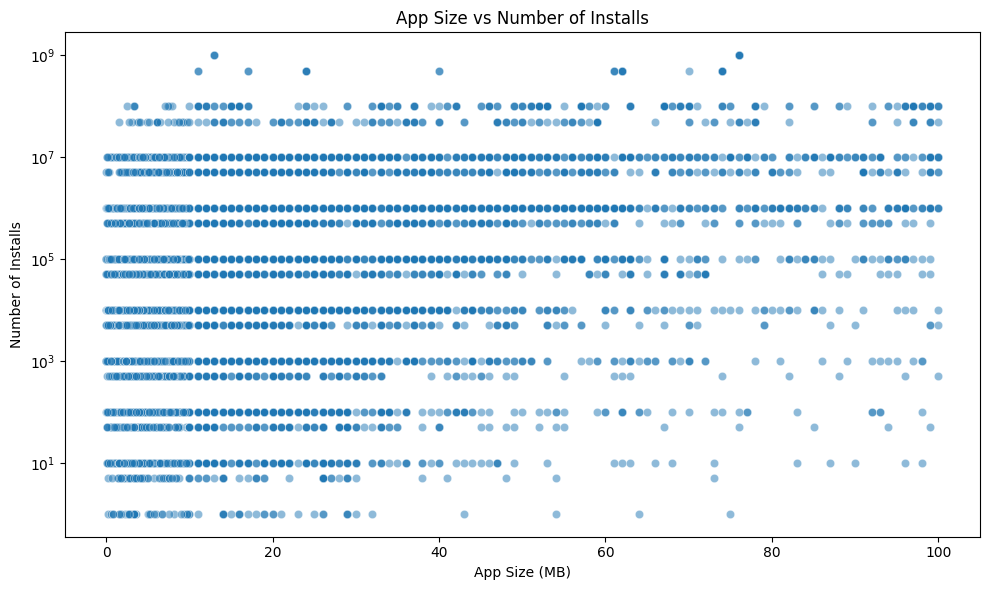

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_analysis,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.yscale("log")
plt.tight_layout()
plt.show()

## 6. Pricing Analysis

The Google Play Store contains both free and paid applications.

This analysis compares the number of free and paid apps and examines the distribution of prices among paid applications.

In [78]:
# Separate paid apps
paid_apps = apps[apps["Type"] == "Paid"].copy()

print("Number of paid apps:", len(paid_apps))

print("\nPrice statistics for paid apps:")
display(paid_apps["Price"].describe())

Number of paid apps: 765

Price statistics for paid apps:


count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

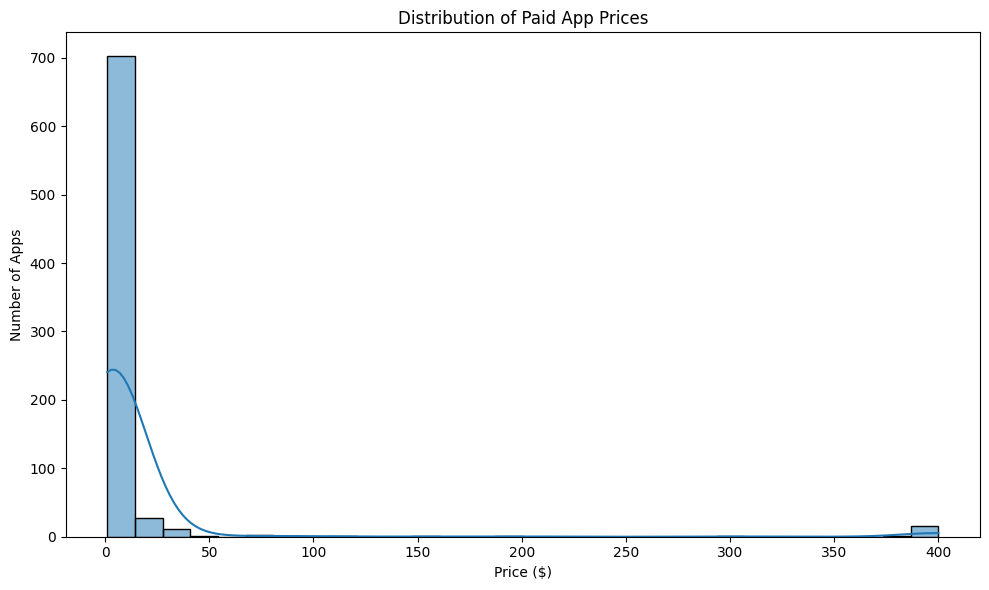

In [79]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Paid App Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

In [80]:
most_expensive = (
    paid_apps[["App", "Price"]]
    .sort_values("Price", ascending=False)
    .head(10)
)

print("Top 10 Most Expensive Apps:")
display(most_expensive)

Top 10 Most Expensive Apps:


,App,Price
4367,I'm Rich - Trump Edition,400.00
5356,I Am Rich Premium,399.99
5369,I am Rich,399.99
5351,I am rich,399.99
5354,I am Rich Plus,399.99
5358,I am Rich!,399.99
4362,💎 I'm rich,399.99
4197,most expensive app (H),399.99
9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,399.99
5373,I AM RICH PRO PLUS,399.99


In [81]:
type_installs = (
    apps.groupby("Type")["Installs"]
    .agg(["count", "mean", "median"])
)

print("Install Statistics by App Type:")
display(type_installs)

Install Statistics by App Type:


,count,mean,median
Type,,,
0,1,1.000000e+05,100000.0
Free,9592,1.527968e+07,100000.0
Paid,765,9.049135e+04,1000.0


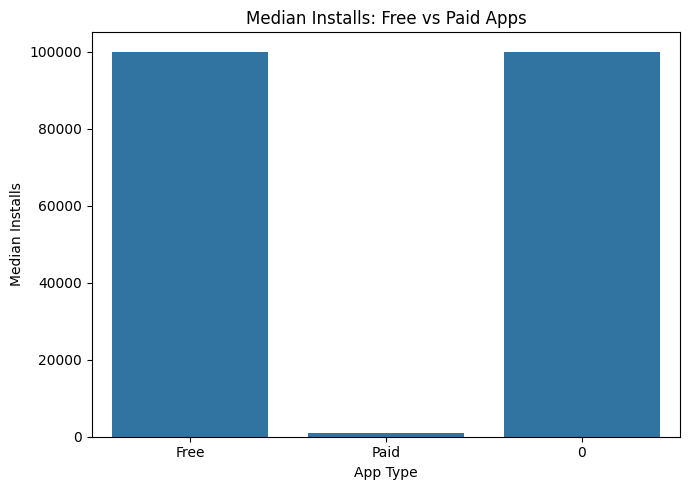

In [82]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=apps,
    x="Type",
    y="Installs",
    estimator=np.median
)

plt.title("Median Installs: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Median Installs")

plt.tight_layout()
plt.show()

## 7. User Review Sentiment Analysis

The Google Play Store User Reviews dataset contains user-written reviews and their associated sentiment labels.

Sentiment analysis is used to understand whether users generally express positive, negative, or neutral opinions about applications.

In [83]:
print("Reviews dataset shape:", reviews.shape)

print("\nReviews columns:")
print(reviews.columns.tolist())

print("\nMissing values:")
print(reviews.isnull().sum())

print("\nDuplicate rows:")
print(reviews.duplicated().sum())

display(reviews.head())

Reviews dataset shape: (64295, 5)

Reviews columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Missing values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Duplicate rows:
33616


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [84]:
# Keep only rows with a review and sentiment
reviews_clean = reviews.dropna(
    subset=["Translated_Review", "Sentiment"]
).copy()

print("Reviews before cleaning:", len(reviews))
print("Reviews after cleaning:", len(reviews_clean))

print("\nSentiment distribution:")
display(reviews_clean["Sentiment"].value_counts())

Reviews before cleaning: 64295
Reviews after cleaning: 37427

Sentiment distribution:


Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

### Sentiment Distribution

The distribution of positive, neutral, and negative reviews is visualized to understand the overall sentiment of Google Play Store users.

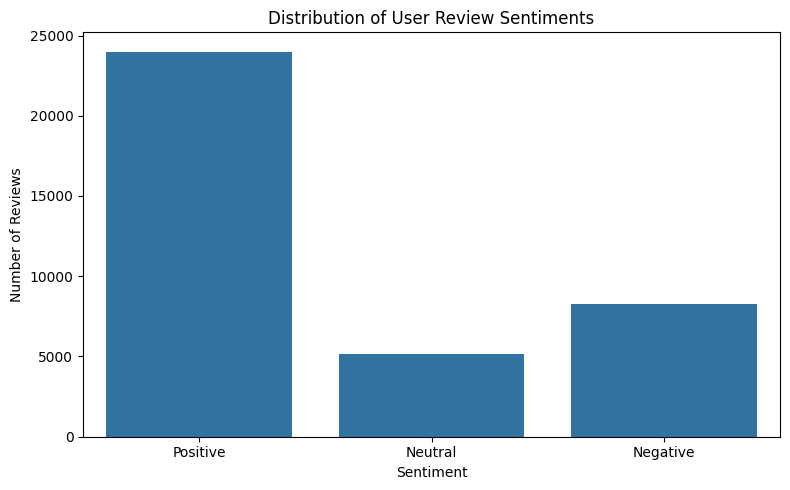

In [85]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews_clean,
    x="Sentiment"
)

plt.title("Distribution of User Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [86]:
positive_reviews = (
    reviews_clean[reviews_clean["Sentiment"] == "Positive"]
    .groupby("App")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Apps by Positive Reviews:")
display(positive_reviews)

Top 10 Apps by Positive Reviews:


App
Helix Jump                        209
Duolingo: Learn Languages Free    200
Calorie Counter - Macros          174
Calorie Counter - MyFitnessPal    169
Bowmasters                        169
10 Best Foods for You             162
Google Photos                     143
8fit Workouts & Meal Planner      137
Garena Free Fire                  136
DRAGON BALL LEGENDS               127
dtype: int64

In [87]:
negative_reviews = (
    reviews_clean[reviews_clean["Sentiment"] == "Negative"]
    .groupby("App")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Apps by Negative Reviews:")
display(negative_reviews)

Top 10 Apps by Negative Reviews:


App
Angry Birds Classic      147
Candy Crush Saga         126
Bowmasters               119
8 Ball Pool              106
Candy Crush Soda Saga     96
Garena Free Fire          81
Cooking Fever             79
Alto's Adventure          72
Block Puzzle              71
Agar.io                   66
dtype: int64

In [88]:
sentiment_percentage = pd.crosstab(
    reviews_clean["Sentiment"],
    columns="Percentage",
    normalize=True
) * 100

print("Overall Sentiment Percentage:")
display(sentiment_percentage.round(2))

Overall Sentiment Percentage:


col_0,Percentage
Sentiment,
Negative,22.10
Neutral,13.78
Positive,64.12


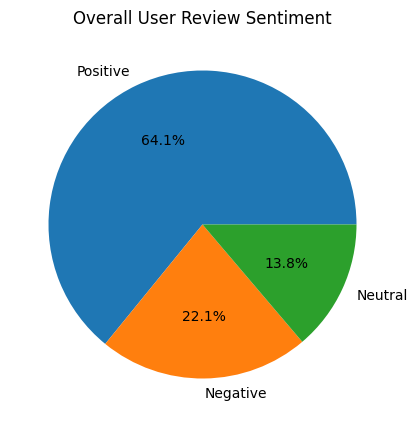

In [89]:
sentiment_counts = reviews_clean["Sentiment"].value_counts()

plt.figure(figsize=(8, 5))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Overall User Review Sentiment")

plt.show()

## 8. Key Insights

### Insight 1 — Positive sentiment dominates

Positive reviews represent **64.12%** of all analyzed user reviews, making them the largest sentiment category. This indicates that users generally expressed favorable opinions about the apps.

### Insight 2 — Negative sentiment is significant

Negative reviews account for **22.10%** of reviews. Although positive sentiment is much higher, more than one-fifth of reviews are negative, highlighting areas where app developers may need to improve user experience.

### Insight 3 — Neutral reviews represent a smaller share

Neutral reviews account for **13.78%** of all analyzed reviews. This is substantially lower than the positive sentiment share, suggesting that most users who provided reviews expressed either positive or negative opinions rather than remaining neutral.

## 9. Conclusion

This project analyzed the Google Play Store Apps and User Reviews datasets to understand the Android app market.

The analysis included data cleaning, duplicate removal, missing-value handling, category analysis, rating analysis, app size and installation analysis, pricing analysis, and user review sentiment analysis.

The Google Play Store contains applications across many categories, with some categories having substantially more apps than others. Ratings were also analyzed to understand the overall user satisfaction associated with applications.

The analysis of free and paid applications showed differences in app availability and installation patterns. App size and installation counts were also examined to understand whether application size is associated with popularity.

Sentiment analysis of user reviews showed that **64.12% of reviews were positive, 22.10% were negative, and 13.78% were neutral**. Positive sentiment was therefore the dominant sentiment among the analyzed reviews.

Overall, the analysis demonstrates how exploratory data analysis and sentiment analysis can be used to understand app popularity, user satisfaction, pricing, and market trends in the Google Play Store.

In [90]:
print("Final Apps Dataset Shape:", apps.shape)
print("Final Reviews Dataset Shape:", reviews_clean.shape)

print("\nMissing values in Apps dataset:")
print(apps.isnull().sum().sum())

print("\nMissing values in Reviews dataset:")
print(reviews_clean.isnull().sum().sum())

Final Apps Dataset Shape: (10358, 15)
Final Reviews Dataset Shape: (37427, 5)

Missing values in Apps dataset:
1527

Missing values in Reviews dataset:
0


In [91]:
print("Missing values by column:")
missing_apps = apps.isnull().sum()

display(
    missing_apps[missing_apps > 0]
    .sort_values(ascending=False)
)

Missing values by column:


Size_MB    1527
dtype: int64

In [92]:
# Verify that the original important columns have no missing values

important_columns = [
    "App", "Category", "Rating", "Reviews", "Size",
    "Installs", "Type", "Price", "Content Rating",
    "Genres", "Last Updated", "Current Ver", "Android Ver"
]

print("Missing values in original dataset columns:")
display(apps[important_columns].isnull().sum())

print("\nTotal missing values in original dataset columns:",
      apps[important_columns].isnull().sum().sum())

Missing values in original dataset columns:


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


Total missing values in original dataset columns: 0


## 10. Handling Application Size

The original `Size` column contains some values listed as "Varies with device". These values cannot be converted into a fixed numerical size and were therefore represented as missing values in the derived `Size_MB` column.

The original `Size` information was retained, while `Size_MB` was used only for numerical size analysis. Applications without a numerical size were excluded only from the Size vs Installs analysis and were not removed from the main dataset.

In [93]:
print("Apps dataset:", apps.shape)
print("Reviews dataset:", reviews_clean.shape)

print("\nOriginal Apps columns:", len(important_columns))
print("Missing values in original Apps columns:",
      apps[important_columns].isnull().sum().sum())

print("Missing values in Reviews dataset:",
      reviews_clean.isnull().sum().sum())

Apps dataset: (10358, 15)
Reviews dataset: (37427, 5)

Original Apps columns: 13
Missing values in original Apps columns: 0
Missing values in Reviews dataset: 0
